# Movement metric calibration

How well each movement score in `classes/analyzer.py` separates the mites labelled **moving** from those labelled **still**, after its parameters were tuned with Optuna.

**Where the numbers come from:** `scripts/optuna_metrics.py` scores every labelled (mite, recording) in `calibration_data/` exactly as a calibration would, and searches each metric's parameters for the best AUC. The studies live in `calibration_data/reports/optuna_metrics.db`, and this notebook only reads them.

**Why there are two searches per metric:** picking the best of hundreds of trials on the same few mites partly fits noise. So the mites are split into two halves:

- **tuned on all:** searched on every mite. This is the setting you'd put in `config.yaml`, but its score is optimistic.
- **tuned on A, judged on B:** searched on half A only, then scored on half B, which the search never saw. This is the honest estimate, and the one the rankings below use.

To refresh the results after labelling more mites, run `python scripts/optuna_metrics.py --study <name>`, set `STUDY` below to that name, and rerun this notebook.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path[:0] = [str(ROOT), str(ROOT / "scripts")]

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import display

from classes import calibration
from classes.analyzer import Analyzer
from optuna_metrics import PADS, STORAGE, split_halves, study_name
from tune_optical_flow import load_observations

# The project's reporting module switches matplotlib to Agg (no figures) on import.
%matplotlib inline

STUDY = "v3"  # the --study name given to scripts/optuna_metrics.py

# Chart style: thin marks, recessive axes and grid, text in ink colours.
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8d8c85"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3dc"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.frameon": False, "legend.fontsize": 8.5, "lines.linewidth": 2,
})
optuna.logging.set_verbosity(optuna.logging.WARNING)

## The labelled observations

In [2]:
rois, moving, mites, recordings = load_observations(PADS)
in_a = split_halves(mites)
datasets = pd.Series([m.split("/")[0] for m in mites])
print(f"{len(moving)} observations: {moving.sum()} moving, {(~moving).sum()} still, "
      f"from {len(set(mites))} mites in {datasets.nunique()} datasets")
print(f"half A: {len(set(np.array(mites)[in_a]))} mites, {in_a.sum()} observations; "
      f"half B: {len(set(np.array(mites)[~in_a]))} mites, {(~in_a).sum()} observations")

  ground_truth_90min: 28 mites


  ground_truth_60min: 29 mites


  sample_data: 29 mites
516 observations: 222 moving, 294 still, from 86 mites in 3 datasets
half A: 43 mites, 258 observations; half B: 43 mites, 258 observations


## Results per metric

For each metric: the score with its **default** parameters (the first trial of the search), after **tuning on all** mites, and **tuned on A, judged on B**. The table also gives the accuracy on half B at the threshold that was best on half A, i.e. how often it would be right on mites it was never calibrated on.

In [3]:
def load(metric, holdout):
    try:
        return optuna.load_study(study_name=study_name(STUDY, metric, holdout), storage=STORAGE)
    except KeyError:
        return None

studies = {(m, h): load(m, h) for m in Analyzer.metric_names() for h in (False, True)}
metrics = [m for m in Analyzer.metric_names() if studies[m, False] and studies[m, True]]

rows = []
for metric in metrics:
    tuned, honest = studies[metric, False], studies[metric, True]
    default = tuned.trials[0].user_attrs  # each search starts from the defaults
    rows.append({
        "metric": metric,
        "trials": len(tuned.trials),
        "AUC default": default["auc"],
        "AUC tuned on all": tuned.best_trial.user_attrs["auc"],
        "AUC tuned on A, judged on B": honest.best_trial.user_attrs["auc_b"],
        "accuracy on B": honest.best_trial.user_attrs["accuracy_b"],
        "threshold (tuned on all)": tuned.best_trial.user_attrs["threshold"],
        "parameters (tuned on all)": tuned.best_trial.user_attrs["params"],
    })
summary = pd.DataFrame(rows).sort_values("AUC tuned on A, judged on B", ascending=False).reset_index(drop=True)
with pd.option_context("display.max_colwidth", None, "display.float_format", "{:.3f}".format):
    display(summary)

,metric,trials,AUC default,AUC tuned on all,"AUC tuned on A, judged on B",accuracy on B,threshold (tuned on all),parameters (tuned on all)
0,topN_variability,60,0.991,0.991,0.993,0.950,49.913,{'n': 8}
1,topN_vector_temporal_range,60,0.968,0.990,0.992,0.957,38.500,{'n': 1}
2,topN_temporal_range,60,0.990,0.991,0.991,0.953,32.600,{'n': 5}
3,variability,1,0.987,0.987,0.988,0.965,3.412,{}
4,optical_flow,300,0.624,0.989,0.985,0.950,0.033,"{'window': 9, 'n': 58, 'step': 15, 'winsize': 37, 'levels': 2, 'iterations': 3, 'poly_n': 5, 'poly_sigma': 1.1, 'pad': 12, 'stabilize': 0}"
5,vector_variance,1,0.965,0.965,0.963,0.942,204.916,{}
6,max_diff,1,0.963,0.963,0.953,0.953,14.000,{}
7,mean_diff,1,0.944,0.944,0.932,0.915,1.727,{}
8,vector_diff,1,0.933,0.933,0.930,0.895,117.682,{}
9,topN_binary_flux,150,0.864,0.949,0.911,0.829,0.069,"{'threshold': 98, 'n': 74}"


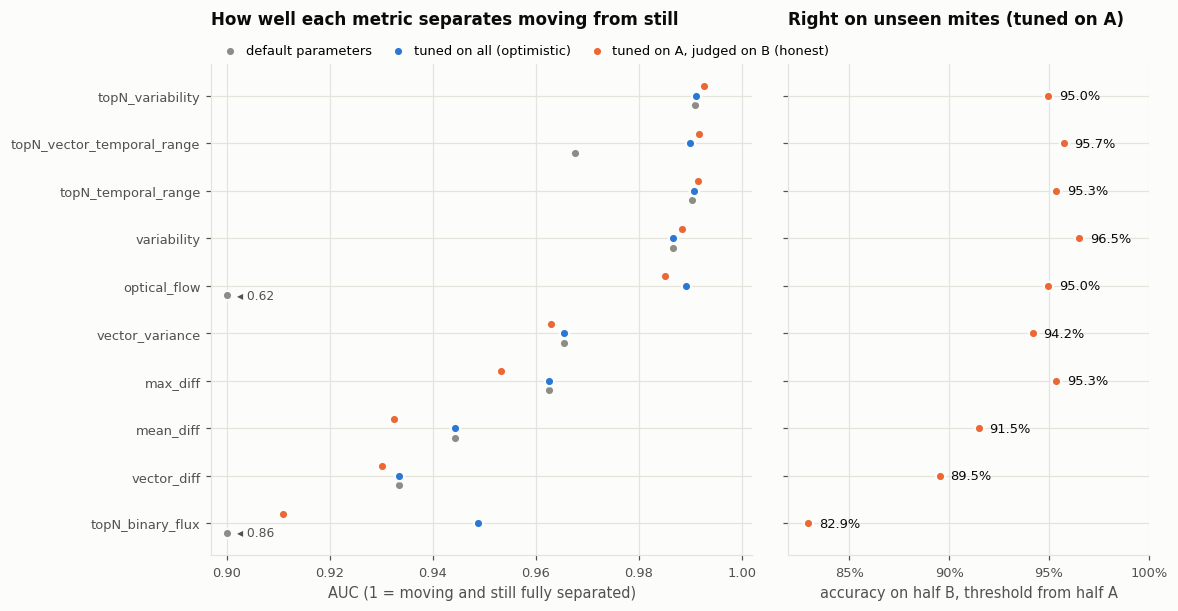

In [4]:
order = summary["metric"][::-1].tolist()  # best at the top
y = np.arange(len(order))
by_metric = summary.set_index("metric").loc[order]
series = [("AUC default", GREY, "default parameters"),
          ("AUC tuned on all", BLUE, "tuned on all (optimistic)"),
          ("AUC tuned on A, judged on B", ORANGE, "tuned on A, judged on B (honest)")]

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 0.42 * len(order) + 1.6), sharey=True,
                              gridspec_kw={"width_ratios": [3, 2], "wspace": 0.08})
# Zoom to the tuned results; a default far below them sits at the edge, labelled.
low = min(0.9, by_metric[["AUC tuned on all", "AUC tuned on A, judged on B"]].min().min() - 0.01)
for (column, color, label), dy in zip(series, (-0.2, 0, 0.2)):
    values = by_metric[column]
    ax.scatter(values.clip(lower=low), y + dy, s=38, color=color, label=label, zorder=3,
               edgecolor="#fcfcfb", linewidth=1.5)
    for yi, value in zip(y, values):
        if value < low:
            ax.annotate(f"◂ {value:.2f}", (low, yi + dy), xytext=(7, 0), textcoords="offset points",
                        va="center", fontsize=8, color=MUTED)
ax.set_xlim(low - 0.003, 1.002)
ax.set_yticks(y, order)
ax.set_xlabel("AUC (1 = moving and still fully separated)")
ax.set_title("How well each metric separates moving from still", loc="left", pad=26)
ax.legend(loc="lower left", bbox_to_anchor=(-0.01, 0.99), ncol=3, handletextpad=0.2, columnspacing=1)

accuracy = by_metric["accuracy on B"]
ax2.scatter(accuracy, y, s=38, color=ORANGE, zorder=3, edgecolor="#fcfcfb", linewidth=1.5)
for yi, value in zip(y, accuracy):
    ax2.annotate(f"{value:.1%}", (value, yi), xytext=(7, 0), textcoords="offset points",
                 va="center", fontsize=8.5, color=INK)
ax2.set_xlim(accuracy.min() - 0.01, 1.0)
ax2.xaxis.set_major_locator(plt.MultipleLocator(0.05))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax2.set_xlabel("accuracy on half B, threshold from half A")
ax2.set_title("Right on unseen mites (tuned on A)", loc="left", pad=26)
plt.show()

## ROC curves

Each panel shows one metric. The **blue** curve is its setting tuned on all mites, scored on all of them. The **orange** curve is its setting tuned on half A, scored on half B. The dot marks the threshold that the calibration would choose. The axes are zoomed to the top-left corner, where the metrics differ.

In [5]:
def score(metric, params):
    cuts = rois[Analyzer.roi_padding(metric, params)]
    return np.array([Analyzer._motion_score(roi, metric, params) for roi in cuts])

# Scoring optical_flow over every observation takes a minute or so.
scores = {m: score(m, studies[m, False].best_trial.user_attrs["params"]) for m in summary["metric"]}
honest_scores = {m: score(m, studies[m, True].best_trial.user_attrs["params"]) for m in summary["metric"]}
thresholds = {m: calibration.best_threshold(s, moving) for m, s in scores.items()}

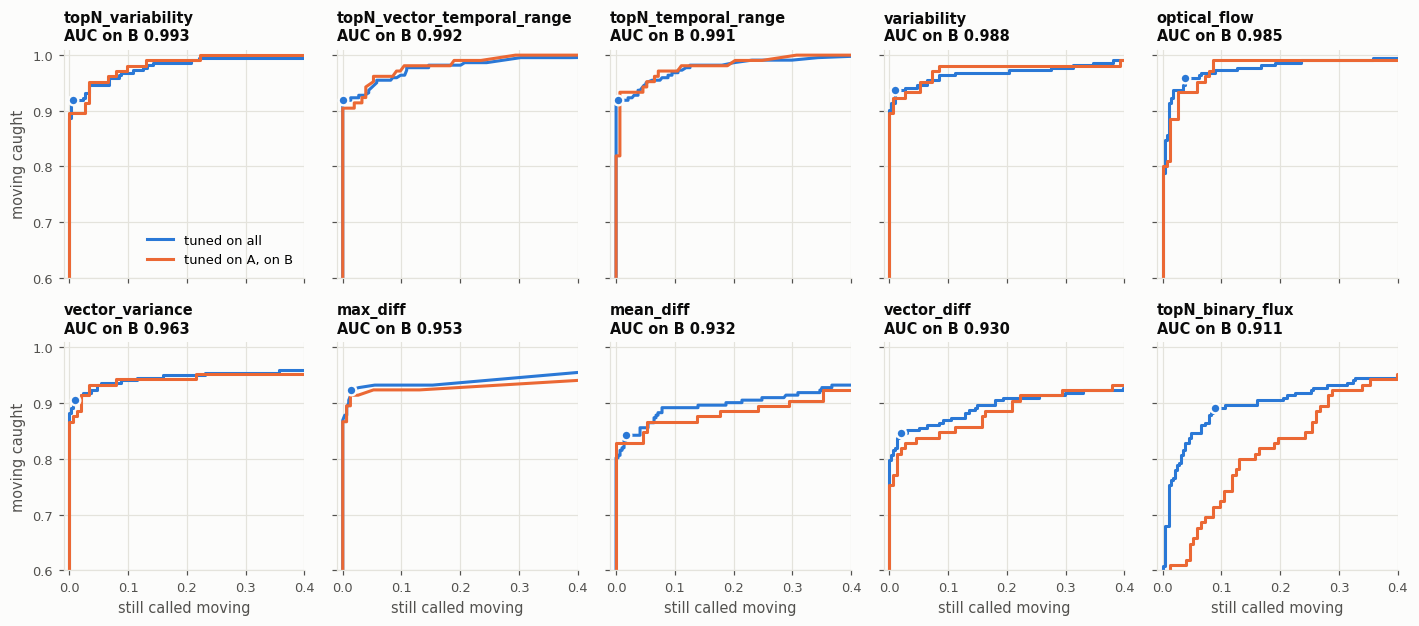

In [6]:
cols = 5
rows_ = int(np.ceil(len(summary) / cols))
fig, axes = plt.subplots(rows_, cols, figsize=(13, 2.9 * rows_), sharex=True, sharey=True)
for ax, metric in zip(axes.flat, summary["metric"]):
    fpr, tpr, _ = calibration.roc_curve(scores[metric], moving)
    ax.plot(fpr, tpr, color=BLUE, label="tuned on all")
    fpr_b, tpr_b, _ = calibration.roc_curve(honest_scores[metric][~in_a], moving[~in_a])
    ax.plot(fpr_b, tpr_b, color=ORANGE, label="tuned on A, on B")
    c = calibration.confusion(scores[metric], moving, thresholds[metric])
    ax.scatter([1 - c["specificity"]], [c["sensitivity"]],
               s=40, color=BLUE, edgecolor="#fcfcfb", linewidth=1.5, zorder=3)
    auc = summary.set_index("metric").loc[metric, "AUC tuned on A, judged on B"]
    ax.set_title(f"{metric}\nAUC on B {auc:.3f}", loc="left", fontsize=9.5)
for ax in axes.flat[len(summary):]:
    ax.set_visible(False)
axes.flat[0].set_xlim(-0.01, 0.4)
axes.flat[0].set_ylim(0.6, 1.01)
for ax in axes[-1]:
    ax.set_xlabel("still called moving")
for ax in axes[:, 0]:
    ax.set_ylabel("moving caught")
axes.flat[0].legend(loc="lower right")
fig.tight_layout()
plt.show()

## Score distributions

The scores of the observations labelled **still** (blue) and **moving** (orange) for each metric's setting tuned on all mites. The dashed line is the threshold the calibration would pick. Anything on the wrong side of it is misclassified. The axis is logarithmic where every score is positive.

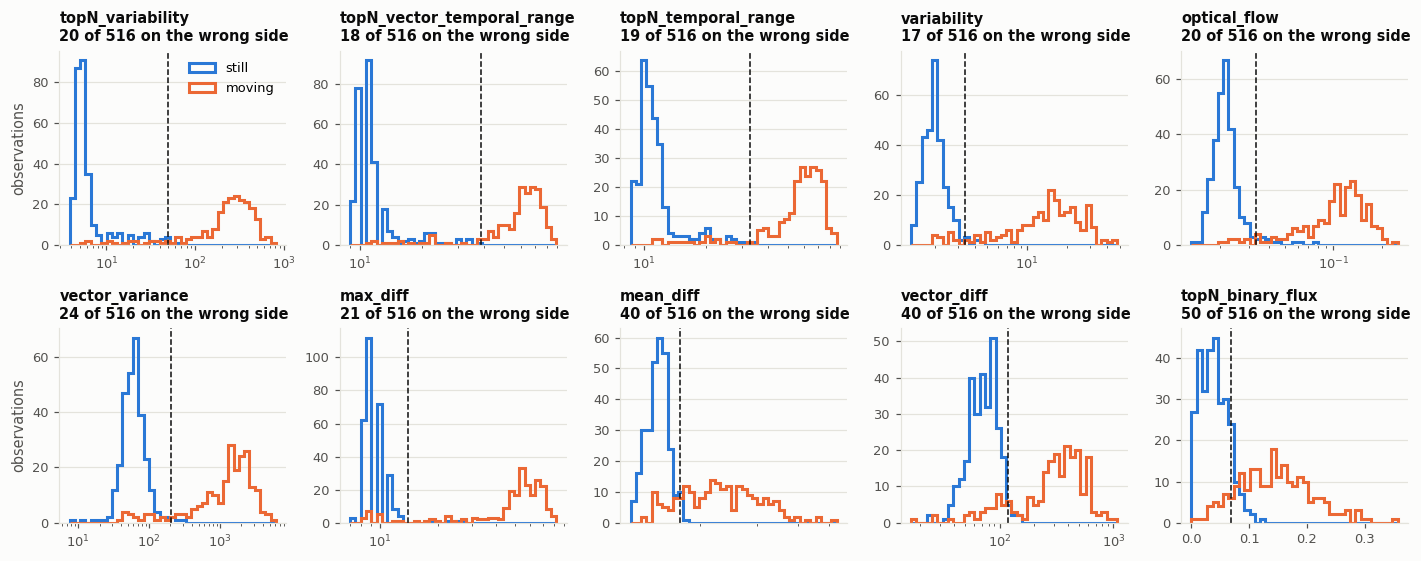

In [7]:
fig, axes = plt.subplots(rows_, cols, figsize=(13, 2.6 * rows_))
for ax, metric in zip(axes.flat, summary["metric"]):
    s = scores[metric]
    log = (s > 0).all()
    bins = np.geomspace(s.min(), s.max(), 40) if log else np.linspace(s.min(), s.max(), 40)
    ax.hist(s[~moving], bins=bins, histtype="step", color=BLUE, linewidth=2, label="still")
    ax.hist(s[moving], bins=bins, histtype="step", color=ORANGE, linewidth=2, label="moving")
    ax.axvline(thresholds[metric], color=INK, linestyle="--", linewidth=1)
    if log:
        ax.set_xscale("log")
        ax.xaxis.set_minor_formatter(plt.NullFormatter())
    wrong = ((s >= thresholds[metric]) != moving).sum()
    ax.set_title(f"{metric}\n{wrong} of {len(s)} on the wrong side", loc="left", fontsize=9.5)
    ax.grid(axis="x", visible=False)
for ax in axes.flat[len(summary):]:
    ax.set_visible(False)
axes.flat[0].legend(loc="upper right")
for ax in axes[:, 0]:
    ax.set_ylabel("observations")
fig.tight_layout()
plt.show()

## The Optuna searches

Each grey dot is one trial's AUC, from the search on all mites. The blue line is the best AUC found so far. A line that flattens early means the search had converged, and more trials would not help. Metrics without parameters are scored once and are left out.

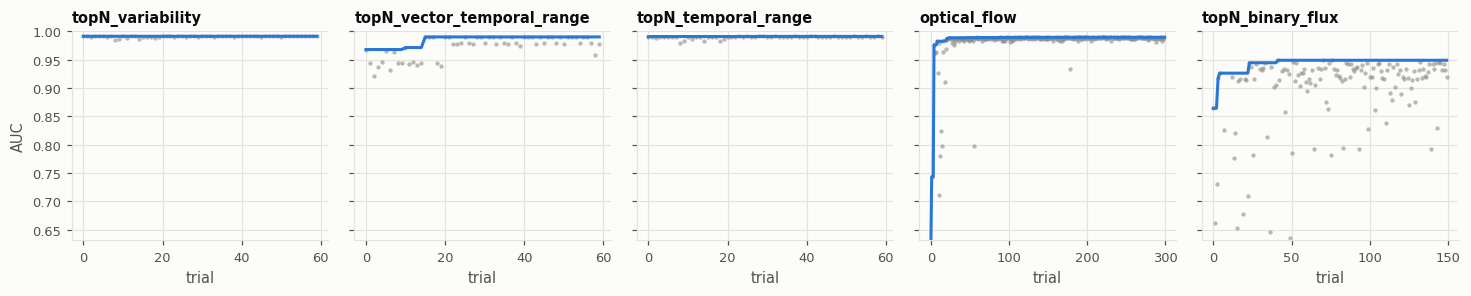

In [8]:
searched = [m for m in summary["metric"] if len(studies[m, False].trials) > 1]
fig, axes = plt.subplots(1, len(searched), figsize=(2.7 * len(searched), 2.8), sharey=True)
for ax, metric in zip(np.atleast_1d(axes), searched):
    values = np.array([t.value if t.value is not None else np.nan for t in studies[metric, False].trials])
    ax.scatter(np.arange(len(values)), values, s=8, color=GREY, alpha=0.6, linewidth=0)
    ax.plot(np.fmax.accumulate(np.nan_to_num(values, nan=0)), color=BLUE)
    ax.set_title(metric, loc="left", fontsize=9.5)
    ax.set_xlabel("trial")
    good = values[np.isfinite(values)]
    ax.set_ylim(max(0.5, np.percentile(good, 10) - 0.02), 1.0)
np.atleast_1d(axes)[0].set_ylabel("AUC")
fig.tight_layout()
plt.show()

## How sensitive the metrics are to their parameters

**Left:** the top-N metrics have a single parameter, `n` (how many of the most active pixels are averaged). Each dot is one trial. A flat curve means the choice of `n` hardly matters.

**Right:** `topN_binary_flux` also has a darkness `threshold` that separates the mite from the background. The dot colour shows the AUC.

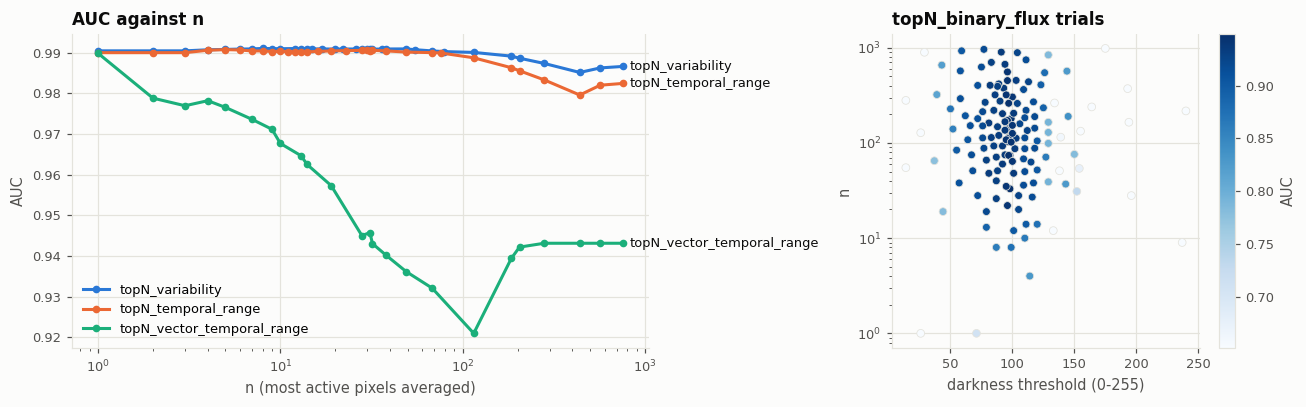

In [9]:
def trials_frame(metric):
    done = [t for t in studies[metric, False].trials if t.value is not None]
    return pd.DataFrame([{**t.params, "auc": t.value} for t in done])

top_n = [m for m in ("topN_variability", "topN_temporal_range", "topN_vector_temporal_range") if m in searched]
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [3, 2]})
for metric, color in zip(top_n, (BLUE, ORANGE, AQUA)):
    frame = trials_frame(metric).groupby("n")["auc"].max().sort_index()
    ax.plot(frame.index, frame.values, color=color, marker="o", markersize=4, label=metric)
    ax.annotate(metric, (frame.index[-1], frame.values[-1]), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8.5, color=INK)
ax.set_xscale("log")
ax.set_xlabel("n (most active pixels averaged)")
ax.set_ylabel("AUC")
ax.set_title("AUC against n", loc="left")
ax.legend(loc="lower left")

if "topN_binary_flux" in searched:
    frame = trials_frame("topN_binary_flux")
    points = ax2.scatter(frame["threshold"], frame["n"], c=frame["auc"], cmap="Blues", s=26,
                         edgecolor=GRID, linewidth=0.5, vmin=max(0.5, frame["auc"].quantile(0.1)))
    ax2.set_yscale("log")
    ax2.set_xlabel("darkness threshold (0-255)")
    ax2.set_ylabel("n")
    ax2.set_title("topN_binary_flux trials", loc="left")
    fig.colorbar(points, ax=ax2, label="AUC")
fig.tight_layout()
plt.show()

## Optical flow: what mattered

The share of the AUC's variation that each parameter explains (Optuna's fANOVA importance), and AUC against `step`, the gap in frames between the two images compared, which matters most.

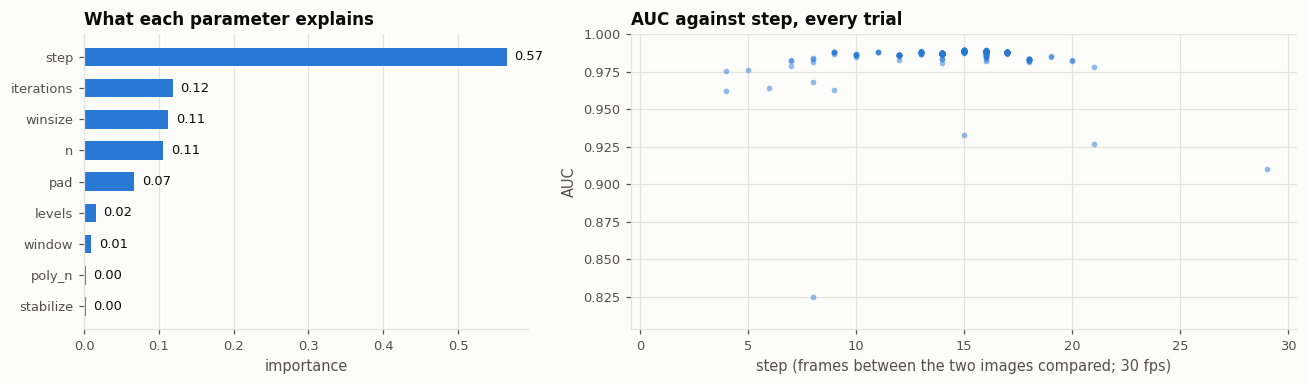

In [10]:
if "optical_flow" in searched:
    study = studies["optical_flow", False]
    importance = pd.Series(optuna.importance.get_param_importances(study)).sort_values()
    frame = trials_frame("optical_flow")
    fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [2, 3]})
    ax.barh(importance.index, importance.values, height=0.6, color=BLUE)
    for yi, value in enumerate(importance.values):
        ax.text(value + 0.01, yi, f"{value:.2f}", va="center", fontsize=8.5, color=INK)
    ax.set_xlabel("importance")
    ax.set_title("What each parameter explains", loc="left")
    ax.grid(axis="y", visible=False)
    ax2.scatter(frame["step"], frame["auc"], s=14, color=BLUE, alpha=0.5, linewidth=0)
    ax2.set_ylim(max(0.5, frame["auc"].quantile(0.05) - 0.02), 1.0)
    ax2.set_xlabel("step (frames between the two images compared; 30 fps)")
    ax2.set_ylabel("AUC")
    ax2.set_title("AUC against step, every trial", loc="left")
    fig.tight_layout()
    plt.show()

## Where the metrics fail together

If the best metrics all get the same observations wrong, a better metric won't fix them. Those observations are genuinely hard, or their label is doubtful. Below, the five best metrics (by the honest AUC) each use their setting tuned on all mites and its threshold. The chart counts how many of the five get each observation wrong.

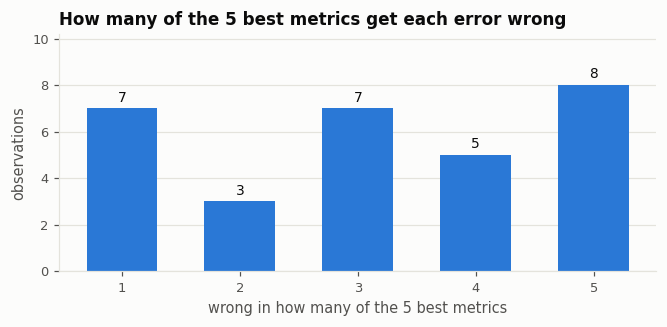

In [11]:
best5 = summary["metric"][:5].tolist()
wrong = np.array([(scores[m] >= thresholds[m]) != moving for m in best5])
n_wrong = wrong.sum(axis=0)
counts = np.bincount(n_wrong, minlength=len(best5) + 1)[1:]

fig, ax = plt.subplots(figsize=(7, 2.8))
ax.bar(np.arange(1, len(best5) + 1), counts, width=0.6, color=BLUE)
for x, c in enumerate(counts, 1):
    ax.text(x, c + 0.3, str(c), ha="center", fontsize=9, color=INK)
ax.set_xticks(np.arange(1, len(best5) + 1))
ax.set_xlabel(f"wrong in how many of the {len(best5)} best metrics")
ax.set_ylabel("observations")
ax.set_title(f"How many of the {len(best5)} best metrics get each error wrong", loc="left")
ax.set_ylim(0, counts.max() * 1.15 + 1)
ax.grid(axis="x", visible=False)
plt.show()

The observations that at least three of the five get wrong are listed below, to review in the calibration page. `recording` is the recording's index in its dataset, counted from 0. The score columns are each metric's score divided by its threshold, so anything above 1 is called moving.

In [12]:
hard = np.flatnonzero(n_wrong >= 3)
table = pd.DataFrame({
    "dataset": [mites[i].split("/")[0] for i in hard],
    "mite": [mites[i].split("/", 1)[1] for i in hard],
    "recording": [recordings[i] for i in hard],
    "label": np.where(moving[hard], "moving", "still"),
    "wrong in": n_wrong[hard],
    **{m: scores[m][hard] / thresholds[m] for m in best5},
}).sort_values(["label", "dataset", "mite", "recording"],
               key=lambda col: pd.to_numeric(col, errors="coerce").fillna(0) if col.name == "mite" else col)
with pd.option_context("display.float_format", "{:.2f}".format, "display.max_rows", 200):
    display(table.reset_index(drop=True))
print(f"{len(table)} observations: {(table['label'] == 'moving').sum()} labelled moving but scored still, "
      f"{(table['label'] == 'still').sum()} labelled still but scored moving")

,dataset,mite,recording,label,wrong in,topN_variability,topN_vector_temporal_range,topN_temporal_range,variability,optical_flow
0,ground_truth_60min-7cf20f8b,13,2,moving,5,0.39,0.52,0.58,0.77,0.84
1,ground_truth_90min-918ce6e1,10,4,moving,3,0.62,0.60,0.68,1.03,2.14
2,ground_truth_90min-918ce6e1,14,1,moving,4,0.63,0.57,0.66,0.77,1.01
3,sample_data-e9dc7400,3,3,moving,5,0.22,0.36,0.42,0.61,0.71
4,sample_data-e9dc7400,3,5,moving,4,0.45,0.42,0.49,0.86,1.78
5,sample_data-e9dc7400,4,2,moving,5,0.32,0.47,0.53,0.65,0.78
6,sample_data-e9dc7400,6,1,moving,3,0.74,0.57,0.63,1.01,1.02
7,sample_data-e9dc7400,6,4,moving,5,0.21,0.39,0.45,0.59,0.67
8,sample_data-e9dc7400,8,3,moving,5,0.18,0.34,0.37,0.60,0.89
9,sample_data-e9dc7400,8,4,moving,3,0.84,0.81,0.83,1.20,1.28


20 observations: 18 labelled moving but scored still, 2 labelled still but scored moving


## Conclusions (study `v3`, 30 Sep 2026: 516 observations, 86 mites, 3 datasets)

These notes were written from the `v3` run. The numbers in them don't update when the notebook is rerun, but the charts above do.

- **Five metrics are tied at the top.** On unseen mites, `topN_variability` (0.993), `topN_vector_temporal_range` (0.992), `topN_temporal_range` (0.991), `variability` (0.988) and `optical_flow` (0.985) all separate moving from still almost perfectly. Each is right on 95.0–96.5% of half B. That spread is 1–4 observations out of 258, which is within noise.
- **The current `config.yaml` setting, `topN_variability` with n=10, is already as good as tuning gets.** Optuna's best is n=11, and anything from n=1 to n=50 is within 0.001 AUC (see *AUC against n*). There is no reason to change it.
- **Tuning helped a lot where the defaults were poor:** `optical_flow` rose from 0.62 to 0.989, `topN_binary_flux` from 0.86 to 0.95, and `topN_vector_temporal_range` from 0.968 to 0.990. But `optical_flow` needs about 300 trials and is far slower to compute, only to tie the simple metrics.
- **`topN_vector_temporal_range` only wins at n=1.** With one pixel, the vector sum is just that pixel's range, so it becomes `topN_temporal_range` with n=1. Summing more pixels as vectors makes it worse (see *AUC against n*). The direction adds nothing here.
- **`topN_binary_flux`, `mean_diff` and `vector_diff` are clearly weaker,** at 0.91–0.93 AUC on unseen mites.
- **Most of the remaining errors are shared.** 20 observations are wrong in at least 3 of the 5 best metrics, and 18 of those are labelled *moving* but score like still mites. 15 of the 20 are in `sample_data`. These are the first thing to check in the calibration page: either the label is wrong, or the movement is too small for any of these metrics. That is where the last few percent are, not in a better metric or more tuning.